# 虚拟电厂案例分析——市场价格与仿真结果可视化

本 notebook 用于论文案例分析，围绕虚拟电厂（VPP）仿真结果，整理基本情况，并绘制能量市场价格与调频市场价格图表，便于论文撰写与结果输出。

## 1. 导入库与设置绘图风格

导入常用数据分析与可视化库，设置中文字体、论文风格、配色方案，确保图表美观且适合论文直接引用。

In [ ]:
# 导入常用库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 设置中文字体和论文风格
plt.rcParams['font.family'] = 'SimHei'  # 适用于Windows中文
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")

# 统一配色方案
color_regcap = "#913A91"  # 调频容量主色
color_regmil = "#357B9C"  # 调频里程主色


## 2. 读取市场参数与仿真结果数据

读取 results 目录下的市场参数和主结果 CSV 文件，检查数据完整性，为后续分析做准备。

In [42]:
# 自动查找 results 目录下最新的市场参数和主结果文件
from glob import glob
from datetime import datetime
import os

# 中文字体支持（自动适应不同操作系统）
import matplotlib.pyplot as plt
import matplotlib
import platform

system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = ['PingFang SC', 'Heiti SC', 'STHeiti']
else:  # Linux
    plt.rcParams['font.family'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

results_dir = 'results'
market_files = sorted(glob(os.path.join(results_dir, 'vpp_market_data_*.csv')))
main_files = sorted(glob(os.path.join(results_dir, 'vpp_results_*.csv')))

if not market_files or not main_files:
    raise FileNotFoundError('未找到市场参数或主结果CSV文件，请先运行仿真脚本生成结果。')

market_file = market_files[-1]
main_file = main_files[-1]
print(f"读取市场参数文件: {market_file}")
print(f"读取主结果文件: {main_file}")

df_market = pd.read_csv(market_file)
df_main = pd.read_csv(main_file)

# 检查数据基本信息
display(df_market.head())
display(df_main.head())
print(f"市场参数时段数: {len(df_market)}，主结果时段数: {len(df_main)}")
print(f"字段: {list(df_market.columns)}")

读取市场参数文件: results\vpp_market_data_20260319_220536.csv
读取主结果文件: results\vpp_results_20260319_220536.csv


,时段,能量价格,调频容量价格,调频里程价格,小时里程
0,1,77.72,24.20,4.67,25.519990
1,2,60.75,33.20,3.98,25.832615
2,3,56.40,29.20,2.65,25.785385
3,4,53.97,10.70,0.00,25.706812
4,5,52.32,11.59,2.92,24.662658


,时段,日前基础功率,日前调频功率,修正后基础功率,修正后调频功率,日前利润,实际利润,日前能量费用,日前容量收益,日前里程收益,实际能量费用,实际容量收益,实际里程收益,实际里程,实际能量,实际成本,修正次数
0,1,-0.000115,1.000053,-1.147105e-04,1.000053e+00,141.082900,1.128691e+02,-0.008915,23.814068,117.277747,-2.935679e+01,2.381407e+01,1.184118e+02,2.576814e+01,-3.777250e-01,60.484813,2.0
1,2,-0.000090,1.000043,-6.770677e-10,-1.183956e-10,133.837847,-3.293779e-08,-0.005457,32.670195,101.173108,-4.103193e-08,-3.867841e-09,1.196198e-08,3.054393e-09,-6.754228e-10,0.000000,2.0
2,3,-0.164501,0.835648,-4.888614e-02,9.511194e-01,70.919862,8.911969e+01,-9.277883,24.010496,56.187249,-4.247004e+00,2.732832e+01,6.603837e+01,2.532535e+01,-7.530149e-02,32.892806,2.0
3,4,0.000019,-0.000002,-4.503262e-08,7.498575e-10,0.001010,-2.421348e-06,0.001029,-0.000019,-0.000000,-2.429243e-06,7.895100e-09,0.000000e+00,2.287700e-08,-4.501100e-08,0.000000,2.0
4,5,-0.285438,0.714571,-2.308193e-01,7.691819e-01,43.851711,5.501371e+01,-14.934135,8.149372,50.636473,-8.291988e+00,8.772181e+00,5.453352e+01,1.897954e+01,-1.584860e-01,25.307219,2.0


市场参数时段数: 24，主结果时段数: 24
字段: ['时段', '能量价格', '调频容量价格', '调频里程价格', '小时里程']


## 3. 整理案例基本情况与关键统计

汇总案例的基本信息，包括研究时段、资源组成、EV 数量、平均基础功率、平均调频功率、总利润等，形成论文描述用表格。

In [43]:
# 统计案例基本信息
case_info = {}
case_info['研究时段'] = f"{df_market['时段'].min()}~{df_market['时段'].max()}"
case_info['时段数'] = len(df_market)
# 资源组成
case_info['资源组成'] = 'PV + ES + EV'
# EV数量推断（主结果表有PV/ES/EV分项时可更精确）
ev_count = None
if 'EV数量' in df_main.columns:
    ev_count = int(df_main['EV数量'].iloc[0])
else:
    # 估算：主结果表无EV数量字段时可根据资源汇总表或NOFDER-2
    ev_count = None
case_info['EV数量'] = ev_count if ev_count is not None else '见资源配置'
# 平均基础功率/调频功率
case_info['平均基础功率(MW)'] = round(df_main['修正后基础功率'].mean(), 3)
case_info['平均调频功率(MW)'] = round(df_main['修正后调频功率'].mean(), 3)
# 总利润
case_info['日前计划总利润(USD)'] = round(df_main['日前利润'].sum(), 2)
case_info['实际总利润(USD)'] = round(df_main['实际利润'].sum(), 2)

case_info_df = pd.DataFrame(list(case_info.items()), columns=['指标', '数值'])
display(case_info_df)


,指标,数值
0,研究时段,1~24
1,时段数,24
2,资源组成,PV + ES + EV
3,EV数量,见资源配置
4,平均基础功率(MW),0.067
5,平均调频功率(MW),0.777
6,日前计划总利润(USD),3925.27
7,实际总利润(USD),1845.88


## 4. 绘制能量市场价格曲线

基于能量价格字段，绘制分时能量市场价格曲线，突出峰谷特征，适合论文插图。

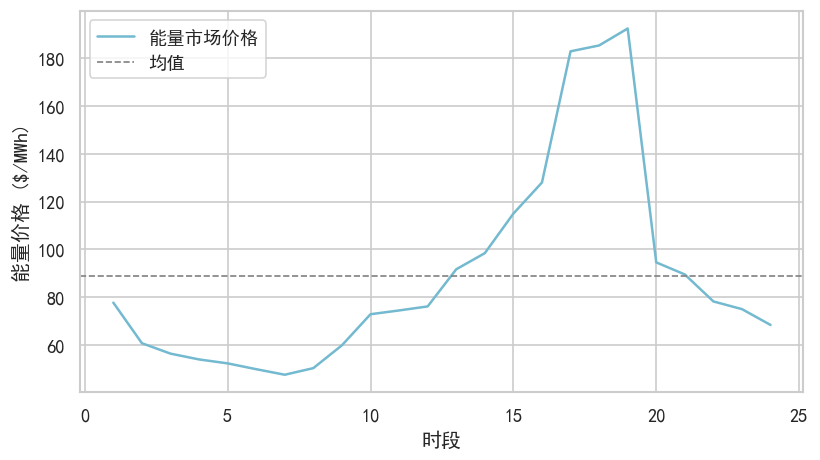

In [59]:
color_energy = "#73B9D0"  # 能量市场主色

# 能量市场价格曲线
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_market['时段'], df_market['能量价格'],  color=color_energy, label='能量市场价格')
ax.set_xlabel('时段')
ax.set_ylabel('能量价格 ($/MWh)')
# 峰谷标记
peak_idx = df_market['能量价格'].idxmax()
valley_idx = df_market['能量价格'].idxmin()
# 均值线
mean_price = df_market['能量价格'].mean()
ax.axhline(mean_price, color='gray', linestyle='--', linewidth=1, label=f'均值')
# 注释最大最小
ax.legend()
plt.tight_layout()
plt.savefig('energy_price_curve.png', bbox_inches='tight')
plt.show()


## 5. 绘制调频市场价格曲线

分别绘制调频容量价格与调频里程价格曲线，突出价格波动特征，适合论文分析。

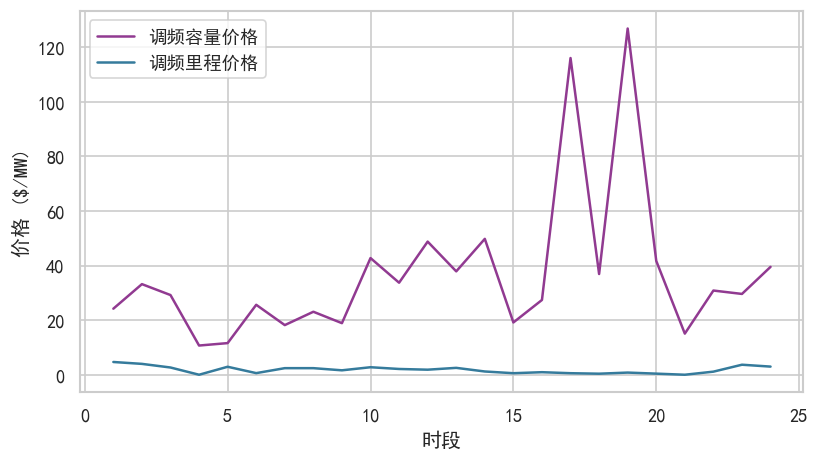

In [53]:
# 调频市场价格曲线
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_market['时段'], df_market['调频容量价格'], color=color_regcap, label='调频容量价格')
ax.plot(df_market['时段'], df_market['调频里程价格'],  color=color_regmil, label='调频里程价格')
ax.set_xlabel('时段')
ax.set_ylabel('价格 ($/MW)')
ax.legend()
plt.tight_layout()
plt.savefig('regulation_price_curve.png', bbox_inches='tight')
plt.show()


## 6. 电动汽车(EV)参数与负荷需求分析

读取EV到离信息，分析各时段在场EV数量变化，绘制负荷需求曲线。

In [60]:
import openpyxl

# 读取EV到离数据
ev_file = os.path.join('data_prepare', 'EV_arrive_leave.xlsx')
wb = openpyxl.load_workbook(ev_file)
ws = wb['EV_arrive_leave']

# 读取所有EV数据
EV_data = []
row_idx = 2
while True:
    row_values = []
    has_data = False
    for col_idx in range(3):
        cell_value = ws.cell(row=row_idx, column=col_idx + 1).value
        if cell_value is not None:
            has_data = True
        row_values.append(cell_value if cell_value is not None else 0.0)
    if not has_data:
        break
    EV_data.append(row_values)
    row_idx += 1
wb.close()

EV_data = np.array(EV_data)
NOFEV = len(EV_data)
NOFSLOTS = 24

print(f"=== EV基本信息 ===")
print(f"EV总数量: {NOFEV}")
print(f"到达时段范围: [{int(EV_data[:, 1].min())}, {int(EV_data[:, 1].max())}]")
print(f"离开时段范围: [{int(EV_data[:, 2].min())}, {int(EV_data[:, 2].max())}]")

# 计算在场状态矩阵 u
u = np.zeros((NOFEV, NOFSLOTS))
for idx in range(NOFEV):
    arrive_slot = int(EV_data[idx, 1]) - 1
    depart_slot = int(EV_data[idx, 2]) - 1
    for jdx in range(NOFSLOTS):
        if arrive_slot <= jdx <= depart_slot:
            u[idx, jdx] = 1.0

# 各时段在场EV数量
ev_count_per_slot = u.sum(axis=0)
print(f"\n=== 各时段在场EV数量 ===")
for t in range(NOFSLOTS):
    print(f"时段{t+1:2d}: {int(ev_count_per_slot[t])} 辆")

# EV参数配置
print(f"\n=== EV参数配置 ===")
print(f"电池容量: 60 kWh")
print(f"初始SOC: 33.3% (20/60 kWh)")
print(f"目标SOC: 83.3% (50/60 kWh)")
print(f"能量上限: 90% (54 kWh)")
print(f"能量下限: 10% (6 kWh)")
print(f"最大充放电功率: 22 kW")
print(f"充放电效率: 90%")
print(f"放电老化成本: 150 $/MWh")
print(f"充电老化成本: 0 $/MWh")

=== EV基本信息 ===
EV总数量: 120
到达时段范围: [8, 10]
离开时段范围: [17, 18]

=== 各时段在场EV数量 ===
时段 1: 0 辆
时段 2: 0 辆
时段 3: 0 辆
时段 4: 0 辆
时段 5: 0 辆
时段 6: 0 辆
时段 7: 0 辆
时段 8: 40 辆
时段 9: 80 辆
时段10: 120 辆
时段11: 120 辆
时段12: 120 辆
时段13: 120 辆
时段14: 120 辆
时段15: 120 辆
时段16: 120 辆
时段17: 120 辆
时段18: 80 辆
时段19: 0 辆
时段20: 0 辆
时段21: 0 辆
时段22: 0 辆
时段23: 0 辆
时段24: 0 辆

=== EV参数配置 ===
电池容量: 60 kWh
初始SOC: 33.3% (20/60 kWh)
目标SOC: 83.3% (50/60 kWh)
能量上限: 90% (54 kWh)
能量下限: 10% (6 kWh)
最大充放电功率: 22 kW
充放电效率: 90%
放电老化成本: 150 $/MWh
充电老化成本: 0 $/MWh
